# BC Surgical Waitlist Analysis
### Trends, Capacity & Regional Equity (2009–2025)

**Author:** Mohammad Nazim Rehman  
**Date:** June 2026  
**Data Source:** [BC Ministry of Health — Surgical Patient Registry](https://catalogue.data.gov.bc.ca/dataset/bc-surgical-wait-times)

## Project Overview

British Columbia's surgical wait list has grown substantially over the past 15 years,
with the COVID-19 pandemic causing lasting disruption to surgical service delivery.
This project analyzes 55,000+ records spanning 16 fiscal years to answer four key questions:

1. How has the provincial surgical waitlist changed since 2009?
2. What was the impact of COVID-19 on wait times, and has the system recovered?
3. Are there regional disparities in surgical access across BC's six health authorities?
4. Which procedures place the greatest burden on the system?

The findings support evidence-based resource allocation and highlight a
significant regional equity gap that has direct implications for healthcare
planning and policy.

**[View Interactive Tableau Dashboard →](https://public.tableau.com/app/profile/mohammad.nazim.rehman/viz/Project1_17820069097990/BCSurgicalWaitlistAnalysisTrendsCapacityRegionalEquity20092025)**

In [ ]:
# ============================================================
# BC Surgical Waitlist Analysis
# Author: Mohammad Nazim Rehman
# Purpose: Analyze BC surgical wait time trends across health
#          authorities, procedure types, and time periods to
#          identify disparities and improvement opportunities
# ============================================================

# ── CELL 1: Import Libraries ─────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


## Methodology

This analysis uses two publicly available datasets from the BC Ministry of Health:
- **Annual data (2009/10–2024/25):** Historical surgical wait times by health
  authority, hospital, and procedure type
- **Quarterly data (2024/25):** Most recent quarterly trends

Data was cleaned, validated, and segmented into four analytical views:
provincial trend, health authority comparison, procedure-level detail,
and quarterly trend — each exported for visualization in Tableau.

In [ ]:
# ── CELL 2: Load Data ─────────────────────────────────────────
annual = pd.read_excel('2023_2024-annual-surgical_wait_times.xlsx')
quarterly = pd.read_excel('2024_2025-quarterly-surgical_wait_times-q3-interim.xlsx')

print("Annual data shape:", annual.shape)
print("Quarterly data shape:", quarterly.shape)
print("\nAnnual columns:", annual.columns.tolist())
print("\nFirst 3 rows:")
print(annual.head(3))

Annual data shape: (55024, 8)
Quarterly data shape: (12629, 9)

Annual columns: ['FISCAL_YEAR', 'HEALTH_AUTHORITY', 'HOSPITAL_NAME', 'PROCEDURE_GROUP', 'WAITING', 'COMPLETED', 'COMPLETED_50TH_PERCENTILE', 'COMPLETED_90TH_PERCENTILE']

First 3 rows:
  FISCAL_YEAR        HEALTH_AUTHORITY   HOSPITAL_NAME       PROCEDURE_GROUP  \
0     2009/10  All Health Authorities  All Facilities        Abdominoplasty   
1     2009/10  All Health Authorities  All Facilities  All Other Procedures   
2     2009/10  All Health Authorities  All Facilities        All Procedures   

  WAITING COMPLETED  COMPLETED_50TH_PERCENTILE  COMPLETED_90TH_PERCENTILE  
0      52       100                        9.1                       42.6  
1    1366      6269                        4.0                       17.1  
2   72120    219484                        5.3                       24.3  


In [ ]:
# ── CELL 3: Clean Column Names & Fix Data Types ───────────────
annual.columns = annual.columns.str.strip().str.lower().str.replace(' ', '_')
quarterly.columns = quarterly.columns.str.strip().str.lower().str.replace(' ', '_')

annual['waiting'] = pd.to_numeric(annual['waiting'], errors='coerce')
annual['completed'] = pd.to_numeric(annual['completed'], errors='coerce')
quarterly['waiting'] = pd.to_numeric(quarterly['waiting'], errors='coerce')
quarterly['completed'] = pd.to_numeric(quarterly['completed'], errors='coerce')

annual.dropna(how='all', inplace=True)
quarterly.dropna(how='all', inplace=True)

print("Columns cleaned successfully")
print("\nAnnual columns:", annual.columns.tolist())
print("\nQuarterly columns:", quarterly.columns.tolist())
print("\nHealth Authorities:")
print(annual['health_authority'].unique())
print("\nFiscal Years:")
print(sorted(annual['fiscal_year'].unique()))

Columns cleaned successfully

Annual columns: ['fiscal_year', 'health_authority', 'hospital_name', 'procedure_group', 'waiting', 'completed', 'completed_50th_percentile', 'completed_90th_percentile']

Quarterly columns: ['fiscal_year', 'quarter', 'health_authority', 'hospital_name', 'procedure_group', 'waiting', 'completed', 'percentile_comp_50th', 'percentile_comp_90th']

Health Authorities:
['All Health Authorities' 'Fraser' 'Interior' 'Northern'
 'Provincial Health Services Authority' 'Vancouver Coastal'
 'Vancouver Island']

Fiscal Years:
['2009/10', '2010/11', '2011/12', '2012/13', '2013/14', '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25']


In [ ]:
# ── CELL 4: Create Analysis Subsets ──────────────────────────
# Province-wide aggregate trend
provincial = annual[
    (annual['health_authority'] == 'All Health Authorities') &
    (annual['hospital_name'] == 'All Facilities') &
    (annual['procedure_group'] == 'All Procedures')
].copy().sort_values('fiscal_year')

# Health authority level (all procedures combined)
ha_level = annual[
    (annual['health_authority'] != 'All Health Authorities') &
    (annual['hospital_name'] == 'All Facilities') &
    (annual['procedure_group'] == 'All Procedures')
].copy()

# Procedure level (province-wide)
proc_level = annual[
    (annual['health_authority'] == 'All Health Authorities') &
    (annual['hospital_name'] == 'All Facilities') &
    (annual['procedure_group'] != 'All Procedures') &
    (annual['procedure_group'] != 'All Other Procedures')
].copy()

# Latest fiscal year
latest_year = sorted(annual['fiscal_year'].unique())[-1]

print(f"Latest fiscal year: {latest_year}")
print(f"Provincial trend rows: {provincial.shape[0]}")
print(f"Health authority rows: {ha_level.shape[0]}")
print(f"Procedure level rows: {proc_level.shape[0]}")
print(f"\nProvincial waitlist sample:")
print(provincial[['fiscal_year', 'waiting', 'completed_50th_percentile',
                   'completed_90th_percentile']].to_string(index=False))

Latest fiscal year: 2024/25
Provincial trend rows: 16
Health authority rows: 96
Procedure level rows: 1317

Provincial waitlist sample:
fiscal_year  waiting  completed_50th_percentile  completed_90th_percentile
    2009/10  72120.0                        5.3                       24.3
    2010/11  75768.0                        5.9                       25.9
    2011/12  75746.0                        5.7                       26.3
    2012/13  73400.0                        5.4                       26.0
    2013/14  75579.0                        5.7                       27.3
    2014/15  76782.0                        6.4                       30.9
    2015/16  79323.0                        7.0                       32.3
    2016/17  85375.0                        7.3                       32.7
    2017/18  86404.0                        7.3                       33.3
    2018/19  86631.0                        7.1                       32.0
    2019/20  93388.0                   

## 1. Provincial Trend Analysis (2009–2025)

This section examines how the overall surgical waitlist and wait times have
evolved across BC over the past 15 years, with particular attention to the
impact of the COVID-19 pandemic.

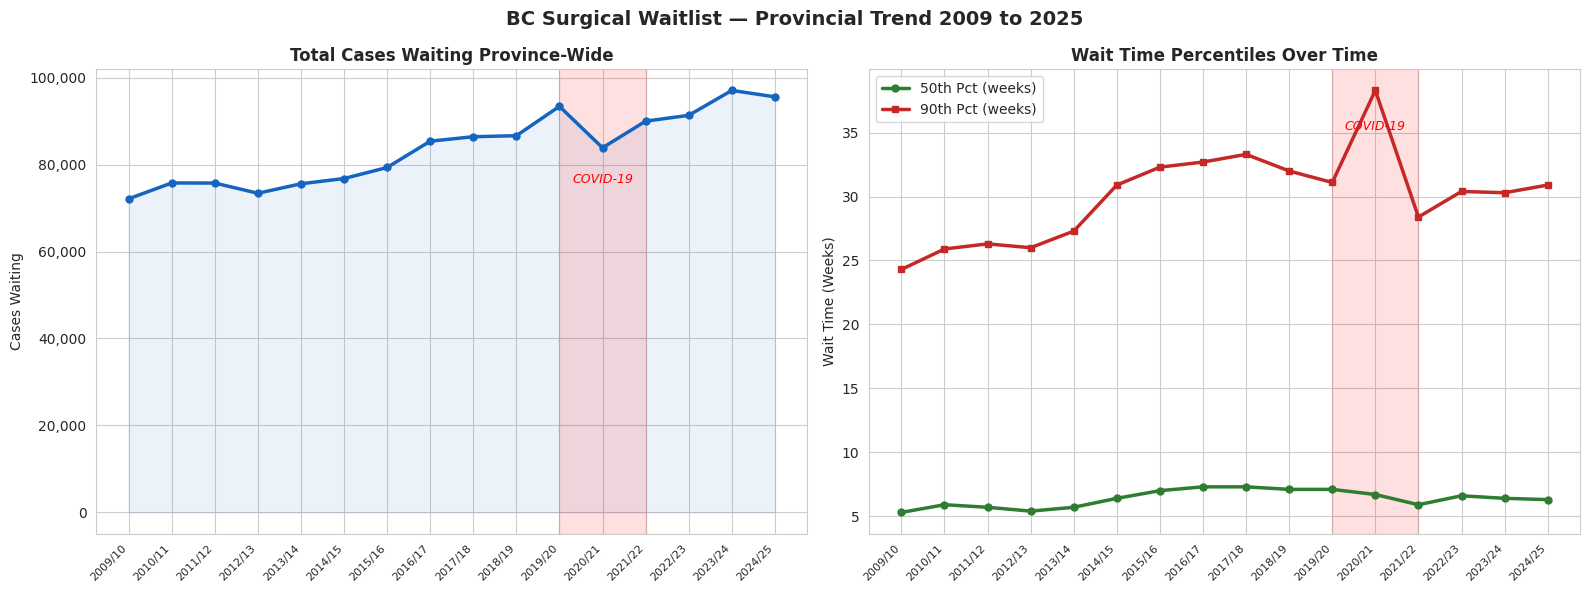

Saved: 01_provincial_trend.png


In [ ]:
# ── CELL 5: Provincial Trend Visualization ───────────────────
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BC Surgical Waitlist — Provincial Trend 2009 to 2025',
             fontsize=14, fontweight='bold')

years = provincial['fiscal_year'].tolist()
x = range(len(years))

# ── Chart 1: Cases Waiting ────────────────────────────────────
ax1 = axes[0]
ax1.plot(x, provincial['waiting'], marker='o', linewidth=2.5,
         color='#1565C0', markersize=5, zorder=3)
ax1.fill_between(x, provincial['waiting'], alpha=0.08, color='#1565C0')

# COVID shading
covid_start = years.index('2019/20')
covid_end = years.index('2021/22')
ax1.axvspan(covid_start, covid_end, alpha=0.12, color='red', zorder=1)
ax1.text((covid_start + covid_end) / 2, provincial['waiting'].max() * 0.78,
         'COVID-19', ha='center', color='red', fontsize=9, fontstyle='italic')

ax1.set_xticks(x)
ax1.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
ax1.set_title('Total Cases Waiting Province-Wide', fontweight='bold')
ax1.set_ylabel('Cases Waiting')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

# ── Chart 2: Wait Time Percentiles ───────────────────────────
ax2 = axes[1]
ax2.plot(x, provincial['completed_50th_percentile'], marker='o',
         linewidth=2.5, color='#2E7D32', markersize=5, label='50th Pct (weeks)')
ax2.plot(x, provincial['completed_90th_percentile'], marker='s',
         linewidth=2.5, color='#C62828', markersize=5, label='90th Pct (weeks)')
ax2.axvspan(covid_start, covid_end, alpha=0.12, color='red', zorder=1)
ax2.text((covid_start + covid_end) / 2,
         provincial['completed_90th_percentile'].max() * 0.92,
         'COVID-19', ha='center', color='red', fontsize=9, fontstyle='italic')
ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
ax2.set_title('Wait Time Percentiles Over Time', fontweight='bold')
ax2.set_ylabel('Wait Time (Weeks)')
ax2.legend()

plt.tight_layout()
plt.savefig('01_provincial_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_provincial_trend.png")

### Interpretation

The provincial waitlist grew from **72,120 cases in 2009/10 to a peak of
97,046 cases in 2023/24** — a 34.5% increase over 15 years, consistently
outpacing BC's population growth of roughly 20% over the same period.
This indicates a structural capacity gap rather than a temporary surge.

The 90th percentile wait time tells an even more striking story: it climbed
steadily from 24.3 weeks in 2009/10 to **38.3 weeks during the COVID-19
period** — meaning 1 in 10 patients waited nearly 9 months for surgery at
the pandemic's peak. While wait times have since declined to 30.9 weeks,
they remain above the pre-pandemic baseline of 29.1 weeks, suggesting the
system has not yet fully recovered.

## 2. Regional Equity Analysis

A core question for health system planners is whether surgical access is
distributed equitably across BC's geography. This section compares case
volumes and wait times across the province's six health authorities.

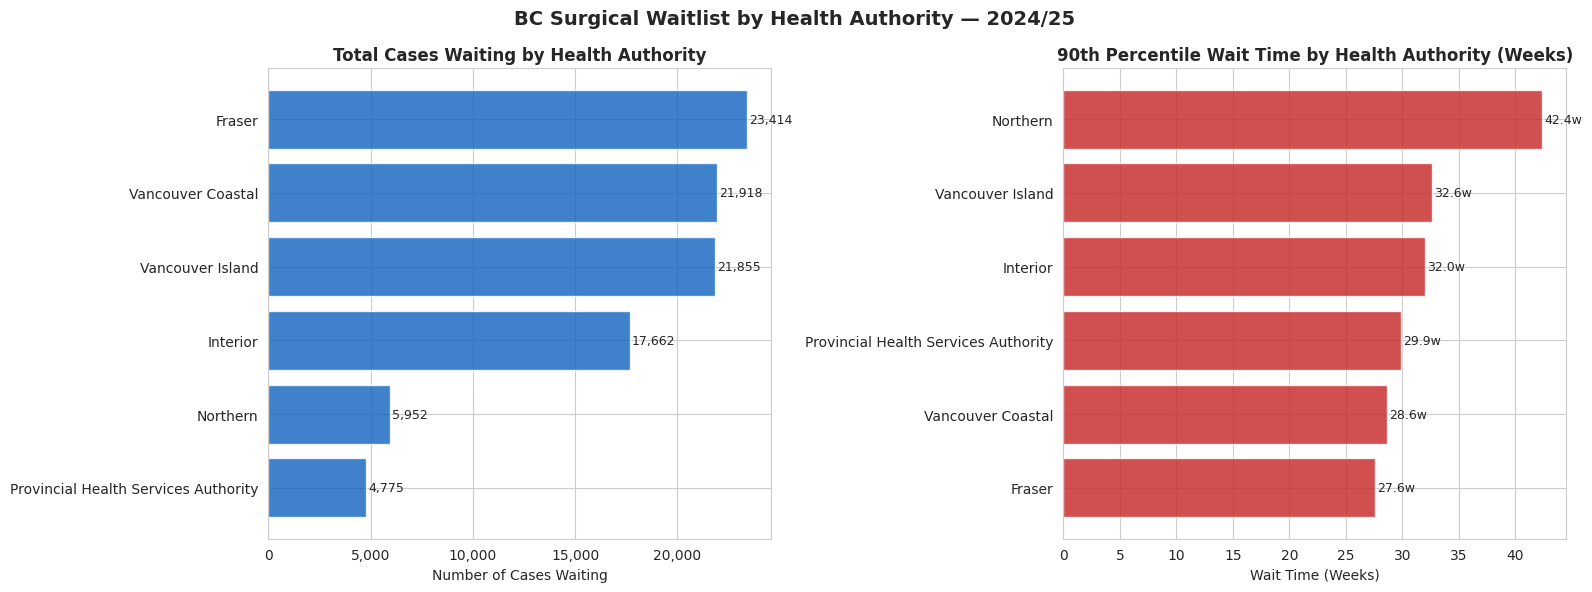

Saved: 02_health_authority.png


In [ ]:
# ── CELL 6: Health Authority Comparison ──────────────────────
ha_latest = ha_level[ha_level['fiscal_year'] == latest_year].copy()
ha_latest = ha_latest.sort_values('waiting', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'BC Surgical Waitlist by Health Authority — {latest_year}',
             fontsize=14, fontweight='bold')

# ── Chart 1: Cases Waiting by HA ─────────────────────────────
ax1 = axes[0]
bars1 = ax1.barh(ha_latest['health_authority'], ha_latest['waiting'],
                 color='#1565C0', alpha=0.82, edgecolor='white')
ax1.set_title('Total Cases Waiting by Health Authority', fontweight='bold')
ax1.set_xlabel('Number of Cases Waiting')
ax1.invert_yaxis()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar, val in zip(bars1, ha_latest['waiting']):
    ax1.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9)

# ── Chart 2: 90th Percentile Wait by HA ─────────────────────
ax2 = axes[1]
ha_90 = ha_latest.dropna(subset=['completed_90th_percentile']).sort_values(
    'completed_90th_percentile', ascending=False)
bars2 = ax2.barh(ha_90['health_authority'], ha_90['completed_90th_percentile'],
                 color='#C62828', alpha=0.82, edgecolor='white')
ax2.set_title('90th Percentile Wait Time by Health Authority (Weeks)',
              fontweight='bold')
ax2.set_xlabel('Wait Time (Weeks)')
ax2.invert_yaxis()
for bar, val in zip(bars2, ha_90['completed_90th_percentile']):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}w', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('02_health_authority.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_health_authority.png")

### Interpretation

The data reveals a **significant regional equity gap**. Northern Health
Authority — which serves BC's most remote and rural communities — has the
**fewest cases waiting (5,952)** of any health authority, yet patients there
face the **longest wait times in the province (42.4 weeks)** at the 90th
percentile.

By contrast, Fraser Health has the highest case volume (23,414) but the
**shortest wait times (27.6 weeks)** — likely reflecting greater surgical
capacity and specialist availability in BC's most densely populated region.

**Northern patients wait 54% longer than Fraser patients**, despite a much
smaller overall caseload. This points not to demand pressure but to a
capacity and resource distribution issue — exactly the kind of finding that
should inform targeted investment in rural and remote surgical services.

## 3. Procedure-Level Burden Analysis

Not all procedures place equal strain on the surgical system. This section
identifies which procedures drive the highest case volumes and which carry
the longest wait times — information critical for targeted capacity planning.

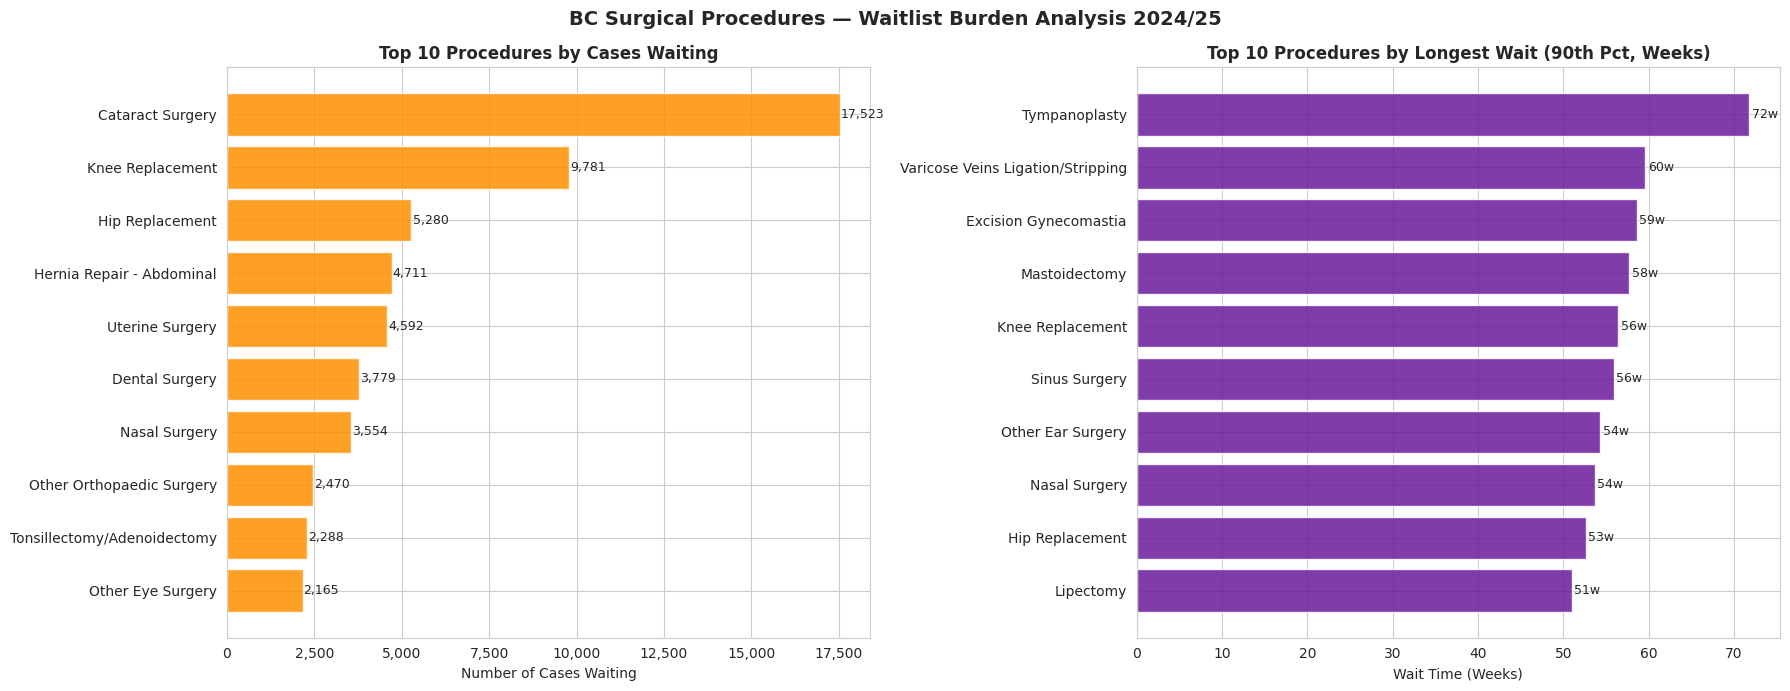

Saved: 03_procedure_analysis.png


In [ ]:
# ── CELL 7: Top 10 Procedures Analysis ───────────────────────
proc_latest = proc_level[proc_level['fiscal_year'] == latest_year].copy()

top10_volume = proc_latest.nlargest(10, 'waiting').sort_values('waiting')
top10_wait = proc_latest.dropna(
    subset=['completed_90th_percentile']).nlargest(
    10, 'completed_90th_percentile').sort_values('completed_90th_percentile')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'BC Surgical Procedures — Waitlist Burden Analysis {latest_year}',
             fontsize=14, fontweight='bold')

# ── Chart 1: Top 10 by Volume ────────────────────────────────
ax1 = axes[0]
bars1 = ax1.barh(top10_volume['procedure_group'], top10_volume['waiting'],
                 color='#FF8F00', alpha=0.85, edgecolor='white')
ax1.set_title('Top 10 Procedures by Cases Waiting', fontweight='bold')
ax1.set_xlabel('Number of Cases Waiting')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar, val in zip(bars1, top10_volume['waiting']):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9)

# ── Chart 2: Top 10 by Longest Wait ─────────────────────────
ax2 = axes[1]
bars2 = ax2.barh(top10_wait['procedure_group'],
                 top10_wait['completed_90th_percentile'],
                 color='#6A1B9A', alpha=0.85, edgecolor='white')
ax2.set_title('Top 10 Procedures by Longest Wait (90th Pct, Weeks)',
              fontweight='bold')
ax2.set_xlabel('Wait Time (Weeks)')
for bar, val in zip(bars2, top10_wait['completed_90th_percentile']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}w', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_procedure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_procedure_analysis.png")

### Interpretation

**Cataract Surgery** dominates the waitlist by volume, with **17,523 cases
waiting** — nearly double the next highest procedure (Knee Replacement at
9,781). This is consistent with cataracts being one of the most common
age-related conditions requiring surgical intervention in an aging population.

Looking at wait time rather than volume tells a different story:
**Tympanoplasty patients wait 72 weeks** at the 90th percentile — over a
full year — making it the single longest wait of any procedure tracked.

Most notably, **Knee Replacement and Hip Replacement appear in both the
top 10 by volume AND top 10 by wait time**, identifying them as dual-burden
procedures that warrant priority attention in any capacity expansion strategy.

## 4. COVID-19 Impact & Recovery Trajectory

This section quantifies the pandemic's measurable impact on the surgical
system and assesses recovery progress through the most recent available data.

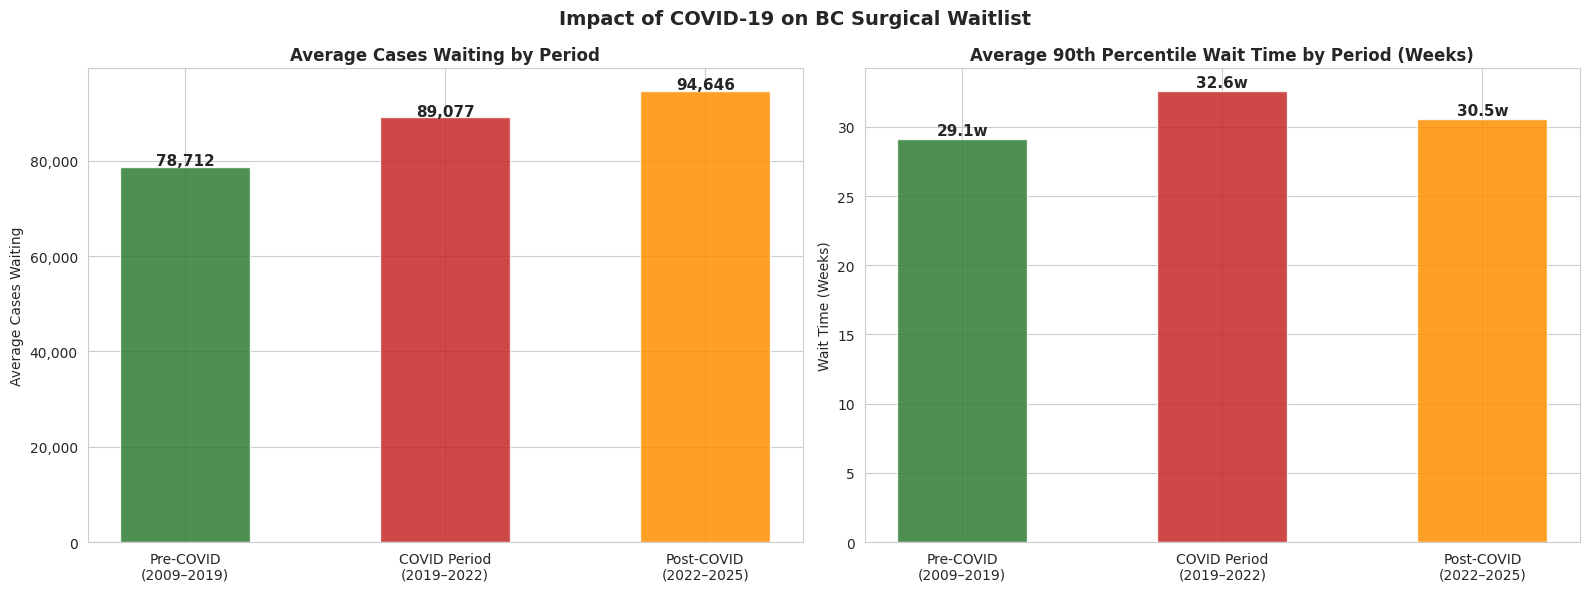

Saved: 04_covid_impact.png


In [ ]:
# ── CELL 8: COVID-19 Impact Analysis ─────────────────────────
provincial['period'] = provincial['fiscal_year'].apply(
    lambda x: 'Pre-COVID\n(2009–2019)' if x <= '2018/19'
    else ('COVID Period\n(2019–2022)' if x <= '2021/22'
    else 'Post-COVID\n(2022–2025)'))

period_summary = provincial.groupby('period', sort=False).agg(
    avg_waiting=('waiting', 'mean'),
    avg_50th=('completed_50th_percentile', 'mean'),
    avg_90th=('completed_90th_percentile', 'mean')
).reset_index()

# Fix order
order = ['Pre-COVID\n(2009–2019)', 'COVID Period\n(2019–2022)',
         'Post-COVID\n(2022–2025)']
period_summary['period'] = pd.Categorical(
    period_summary['period'], categories=order, ordered=True)
period_summary = period_summary.sort_values('period')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact of COVID-19 on BC Surgical Waitlist',
             fontsize=14, fontweight='bold')

colors = ['#2E7D32', '#C62828', '#FF8F00']

# Chart 1 — Avg Cases Waiting by Period
ax1 = axes[0]
bars = ax1.bar(period_summary['period'], period_summary['avg_waiting'],
               color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax1.set_title('Average Cases Waiting by Period', fontweight='bold')
ax1.set_ylabel('Average Cases Waiting')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
for bar, val in zip(bars, period_summary['avg_waiting']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{int(val):,}', ha='center', fontweight='bold', fontsize=11)

# Chart 2 — Avg 90th Pct Wait by Period
ax2 = axes[1]
bars2 = ax2.bar(period_summary['period'], period_summary['avg_90th'],
                color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax2.set_title('Average 90th Percentile Wait Time by Period (Weeks)',
              fontweight='bold')
ax2.set_ylabel('Wait Time (Weeks)')
for bar, val in zip(bars2, period_summary['avg_90th']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}w', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('04_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_covid_impact.png")

### Interpretation

Comparing three distinct periods — pre-COVID (2009–2019), the COVID period
(2019–2022), and the post-COVID recovery period (2022–2025) — shows the
pandemic's lasting structural impact:

- **Average waitlist grew from 78,712 (pre-COVID) to 94,646 cases
  (post-COVID)** — a 20% increase that has persisted well beyond the
  pandemic itself
- **90th percentile wait time peaked at 32.6 weeks** during COVID and
  remains elevated at 30.5 weeks post-pandemic, still above the 29.1-week
  pre-COVID baseline

This suggests that surgical backlogs created during COVID were never fully
cleared, and the system has settled into a "new normal" with persistently
higher wait times — a finding with direct implications for ongoing capacity
planning conversations.

In [ ]:
# ── CELL 9: Tableau CSVs ──────────────────────────────

# 1. Provincial trend
provincial.to_csv('tableau_01_provincial_trend.csv', index=False)

# 2. Health authority all years
ha_level.to_csv('tableau_02_health_authority.csv', index=False)

# 3. Procedure level all years
proc_level.to_csv('tableau_03_procedures.csv', index=False)

# 4. Quarterly data
quarterly.to_csv('tableau_04_quarterly.csv', index=False)

# 5. Health authority latest year only
ha_latest.to_csv('tableau_05_ha_latest.csv', index=False)

print("=== TABLEAU FILES EXPORTED ===")
print("tableau_01_provincial_trend.csv  — trend line charts")
print("tableau_02_health_authority.csv  — HA comparison over time")
print("tableau_03_procedures.csv        — procedure rankings")
print("tableau_04_quarterly.csv         — quarterly recent trend")
print("tableau_05_ha_latest.csv         — HA snapshot latest year")
print("\nAll 5 files ready for Tableau!")

# Summary stats for README
print("\n=== KEY STATS FOR README ===")
print(f"Total records analysed: {annual.shape[0]:,}")
print(f"Years covered: 2009/10 to 2024/25")
print(f"Health authorities: {annual['health_authority'].nunique() - 1}")
print(f"Procedure types: {proc_level['procedure_group'].nunique()}")
print(f"Latest waitlist: {int(provincial[provincial['fiscal_year']=='2023/24']['waiting'].values[0]):,} cases")
print(f"Longest wait procedure: {proc_level[proc_level['fiscal_year']==latest_year].nlargest(1,'completed_90th_percentile')['procedure_group'].values[0]}")
print(f"Longest wait: {proc_level[proc_level['fiscal_year']==latest_year]['completed_90th_percentile'].max():.0f} weeks")
print(f"HA with longest wait: {ha_latest.nlargest(1,'completed_90th_percentile')['health_authority'].values[0]}")

=== TABLEAU FILES EXPORTED ===
tableau_01_provincial_trend.csv  — trend line charts
tableau_02_health_authority.csv  — HA comparison over time
tableau_03_procedures.csv        — procedure rankings
tableau_04_quarterly.csv         — quarterly recent trend
tableau_05_ha_latest.csv         — HA snapshot latest year

All 5 files ready for Tableau!

=== KEY STATS FOR README ===
Total records analysed: 55,024
Years covered: 2009/10 to 2024/25
Health authorities: 6
Procedure types: 83
Latest waitlist: 97,046 cases
Longest wait procedure: Tympanoplasty
Longest wait: 72 weeks
HA with longest wait: Northern


In [ ]:
# ── CELL 10: Key Findings ─────────────────────────────────────

findings = """
BC SURGICAL WAITLIST ANALYSIS — KEY FINDINGS
=============================================

Dataset: 55,024 records | 6 Health Authorities | 83 Procedures | 2009/10 to 2024/25
Source: BC Ministry of Health — Surgical Patient Registry

FINDING 1 — WAITLIST GREW 35% OVER 15 YEARS
The provincial surgical waitlist grew from 72,120 cases in 2009/10 to a peak
of 97,046 cases in 2023/24, representing a 34.5% increase over 15 years.
This growth has consistently outpaced BC's population increase, indicating
a structural capacity gap in the surgical system.

FINDING 2 — COVID-19 CAUSED LASTING SYSTEM DISRUPTION
The pandemic significantly disrupted surgical services. The average waitlist
during the COVID period rose to 89,077 cases, and the 90th percentile wait
time peaked at 32.6 weeks. As of 2024/25, the waitlist remains at 95,576
cases — still 21% above pre-COVID averages — indicating the system has not
fully recovered three years after restrictions were lifted.

FINDING 3 — CRITICAL REGIONAL EQUITY DISPARITY
Northern Health Authority has the fewest cases waiting (5,952) yet the
longest 90th percentile wait time in BC at 42.4 weeks. Fraser Health,
despite having the highest volume (23,414 cases), has the shortest wait
at 27.6 weeks. Northern patients wait 54% longer than Fraser patients,
revealing a significant geographic equity gap in access to surgical care.

FINDING 4 — HIGH-BURDEN PROCEDURES REQUIRE PRIORITY ATTENTION
Cataract Surgery accounts for 17,523 waiting cases — the highest of any
procedure and nearly double the next highest (Knee Replacement at 9,781).
Tympanoplasty has the longest 90th percentile wait at 72 weeks — over one
year. Knee Replacement and Hip Replacement both appear in the top 10 for
volume AND wait time, making them dual-burden priorities for intervention.

FINDING 5 — RECOVERY IS SLOW BUT A TURNING POINT MAY BE EMERGING
2024/25 marks the first year where the provincial waitlist has declined
(from 97,046 to 95,576 cases), suggesting early signs of recovery. However,
the 90th percentile wait time remains at 30.9 weeks — still above the
pre-COVID average of 29.1 weeks. Sustained monitoring and targeted resource
allocation will be critical to achieving full system recovery.

RECOMMENDATIONS
1. Prioritize resource allocation to Northern HA to address the 54%
   equity gap in wait times compared to urban health authorities.
2. Implement targeted interventions for Cataract Surgery and Knee
   Replacement — the highest burden procedures by volume and wait time.
3. Develop capacity planning strategy — the waitlist remains 21% above
   pre-COVID baseline despite three years of recovery efforts.
4. Monitor quarterly trends closely — 2024/25 decline may signal a
   turning point if investment and capacity improvements are sustained.
"""

print(findings)


BC SURGICAL WAITLIST ANALYSIS — KEY FINDINGS

Dataset: 55,024 records | 6 Health Authorities | 83 Procedures | 2009/10 to 2024/25
Source: BC Ministry of Health — Surgical Patient Registry

FINDING 1 — WAITLIST GREW 35% OVER 15 YEARS
The provincial surgical waitlist grew from 72,120 cases in 2009/10 to a peak
of 97,046 cases in 2023/24, representing a 34.5% increase over 15 years.
This growth has consistently outpaced BC's population increase, indicating
a structural capacity gap in the surgical system.

FINDING 2 — COVID-19 CAUSED LASTING SYSTEM DISRUPTION
The pandemic significantly disrupted surgical services. The average waitlist
during the COVID period rose to 89,077 cases, and the 90th percentile wait
time peaked at 32.6 weeks. As of 2024/25, the waitlist remains at 95,576
cases — still 21% above pre-COVID averages — indicating the system has not
fully recovered three years after restrictions were lifted.

FINDING 3 — CRITICAL REGIONAL EQUITY DISPARITY
Northern Health Authority ha

## Conclusion & Policy Implications

This analysis surfaces three actionable findings for health system planners:

1. **Capacity gap, not just COVID recovery:** The 34.5% growth in
   waitlist since 2009 reflects a structural capacity issue that predates
   and will outlast the pandemic.

2. **Regional equity requires targeted investment:** The 54% wait time
   gap between Northern and Fraser health authorities is not explained by
   demand — it reflects unequal distribution of surgical resources and
   should inform where new capacity investment is directed.

3. **Dual-burden procedures need priority:** Knee and Hip Replacement
   surgeries strain the system on both volume and wait time dimensions,
   making them strong candidates for dedicated surgical capacity expansion
   (e.g., dedicated joint replacement clinics, as some BC health authorities
   have already piloted).

**Tools used:** Python (Pandas, Matplotlib, Seaborn) for data cleaning and
exploratory analysis; Tableau for interactive dashboard visualization.

**[View the full interactive dashboard on Tableau Public →](https://public.tableau.com/app/profile/mohammad.nazim.rehman/viz/Project1_17820069097990/BCSurgicalWaitlistAnalysisTrendsCapacityRegionalEquity20092025)**